In [4]:
import pandas as pd

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv('/content/online_retail_II.csv')

In [7]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [8]:
df.shape

(1067371, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [10]:
df.describe()

,Quantity,Price,Customer ID
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [11]:
df.isnull().sum()

,0
Invoice,0
StockCode,0
Description,4382
Quantity,0
InvoiceDate,0
Price,0
Customer ID,243007
Country,0


In [12]:
df.duplicated().sum()

np.int64(34335)

In [13]:
df=df.drop_duplicates()

In [14]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [15]:
df=df.dropna(subset=['Customer ID'])

In [16]:
df=df[df['Quantity']>0]

In [17]:
df=df[df['Price']>0]

In [18]:
df=df[~df['Invoice'].astype(str).str.startswith('C')]

In [19]:
df['Revenue']=df['Quantity']*df['Price']

In [20]:
df.shape

(779425, 9)

In [21]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [43]:
df['Year']=df['InvoiceDate'].dt.year
df['Month']=df['InvoiceDate'].dt.month_name()
df['MonthNumber']=df['InvoiceDate'].dt.month
df['DayOfWeek']=df['InvoiceDate'].dt.day_name()
df['Hour']=df['InvoiceDate'].dt.hour

In [44]:
total_revenue=df['Revenue'].sum()
total_orders=df['Invoice'].nunique()
total_customers=df['Customer ID'].nunique()
average_order_value=total_revenue/total_orders

print("Total Revenue:",total_revenue)
print("total orders:",total_orders)
print("total customers:",total_customers)
print("average order value:",average_order_value)

Total Revenue: 17374804.268000003
total orders: 36969
total customers: 5878
average order value: 469.9830741432011


[]

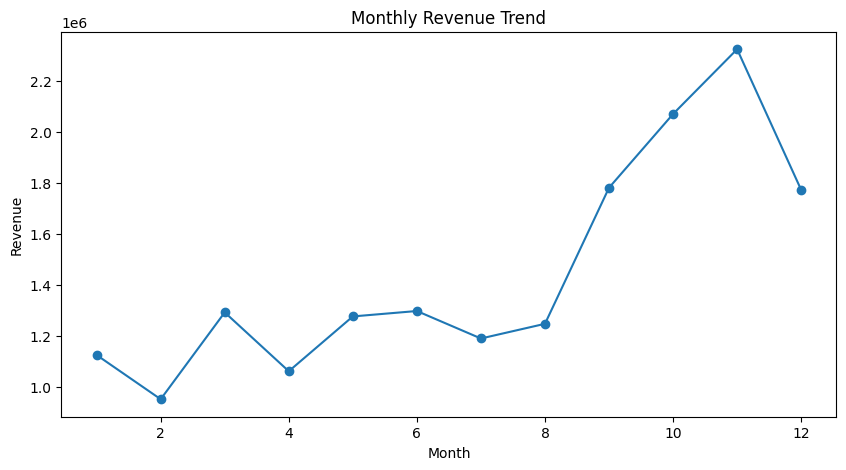

In [45]:
monthly_revenue=df.groupby('MonthNumber')['Revenue'].sum()
plt.figure(figsize=(10,5))
monthly_revenue.plot(marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.plot()


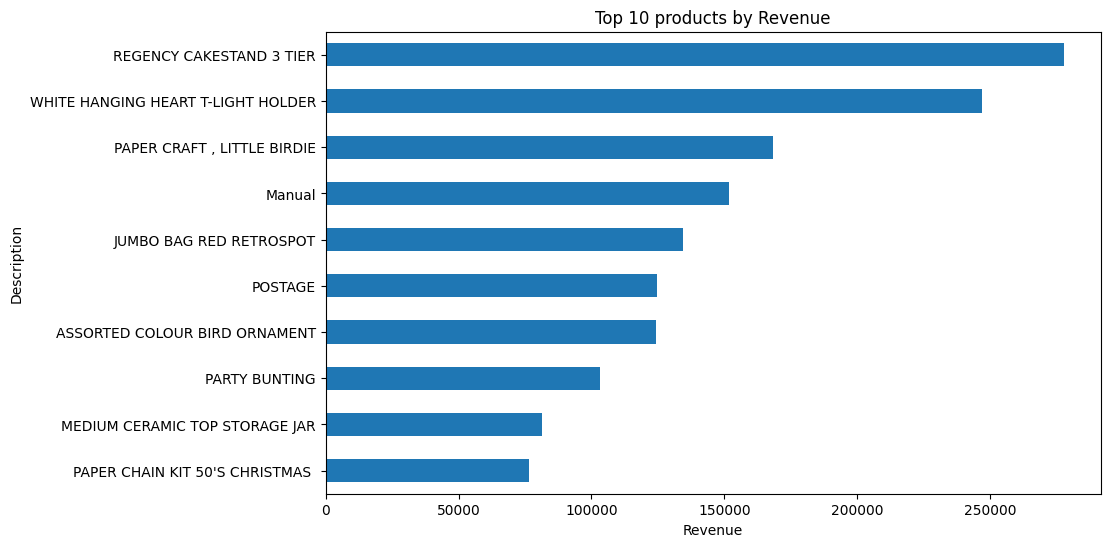

In [46]:
top_products=(
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind='barh')
plt.title('Top 10 products by Revenue')
plt.xlabel('Revenue')
plt.show()

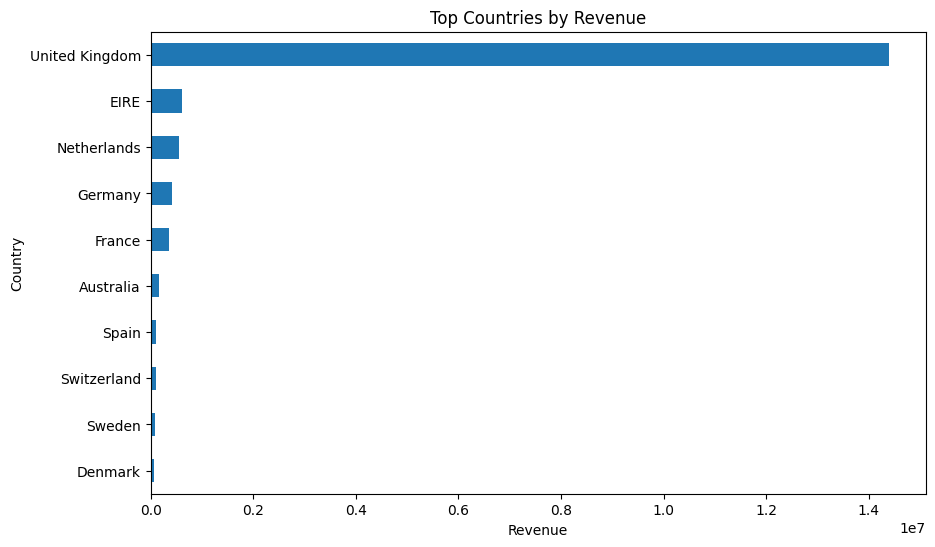

In [47]:
top_countries=(
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_countries.sort_values().plot(kind='barh')
plt.title('Top Countries by Revenue')
plt.xlabel('Revenue')
plt.show()

In [48]:
top_customers=(
    df.groupby('Customer ID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_customers

,Revenue
Customer ID,
18102.0,580987.04
14646.0,528602.52
14156.0,313437.62
14911.0,291420.81
17450.0,244784.25
13694.0,195640.69
17511.0,172132.87
16446.0,168472.50
16684.0,147142.77


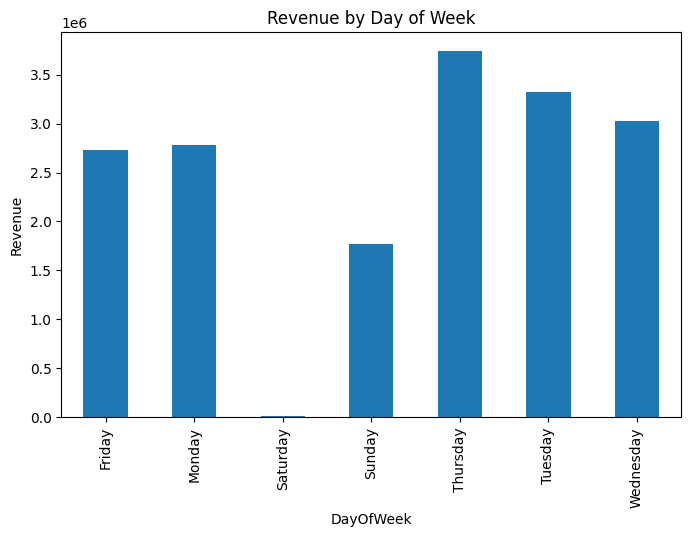

In [49]:
day_sales=df.groupby('DayOfWeek')['Revenue'].sum()
day_sales.plot(kind='bar',figsize=(8,5))
plt.title("Revenue by Day of Week")
plt.ylabel('Revenue')
plt.xlabel('DayOfWeek')
plt.show()

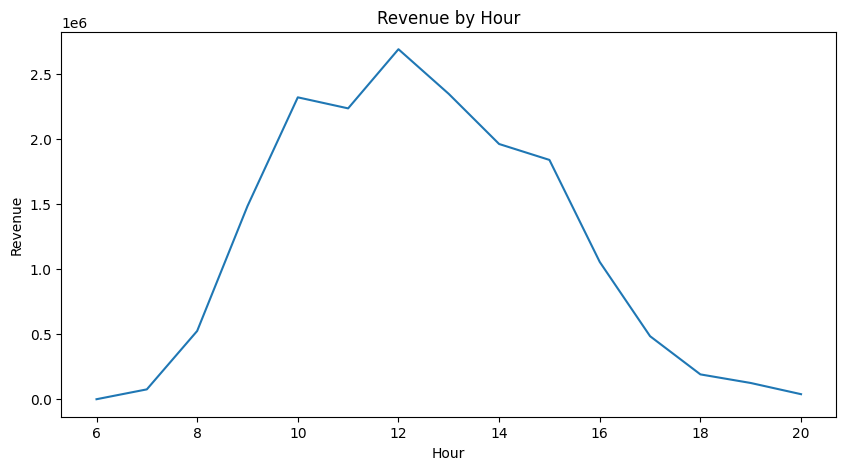

In [50]:
hour_sales=df.groupby('Hour')['Revenue'].sum()

hour_sales.plot(figsize=(10,5))
plt.title('Revenue by Hour')
plt.xlabel('Hour')
plt.ylabel('Revenue')
plt.show()

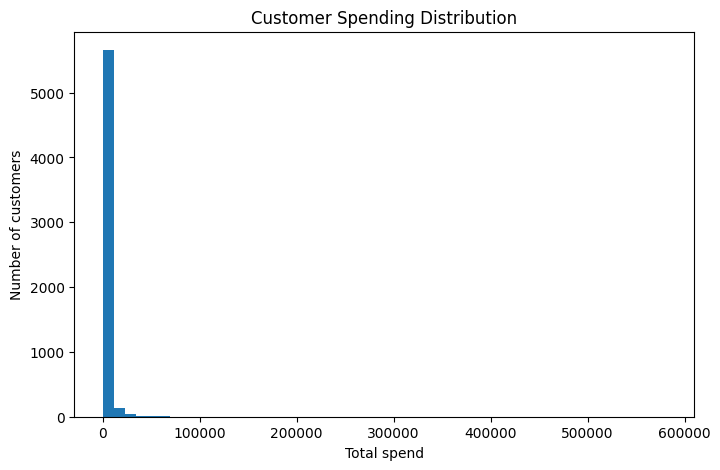

In [51]:
customer_spend=df.groupby('Customer ID')['Revenue'].sum()

plt.figure(figsize=(8,5))
plt.hist(customer_spend,bins=50)
plt.title('Customer Spending Distribution')
plt.xlabel('Total spend')
plt.ylabel('Number of customers')
plt.show()

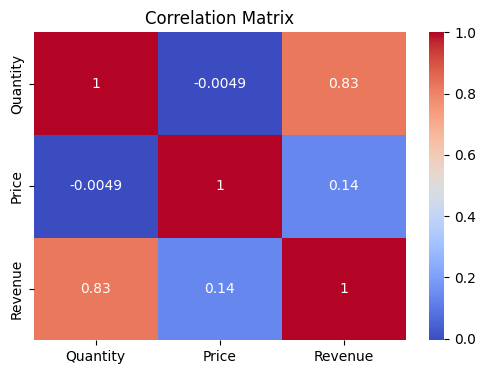

In [52]:
corr = df[['Quantity', 'Price', 'Revenue']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

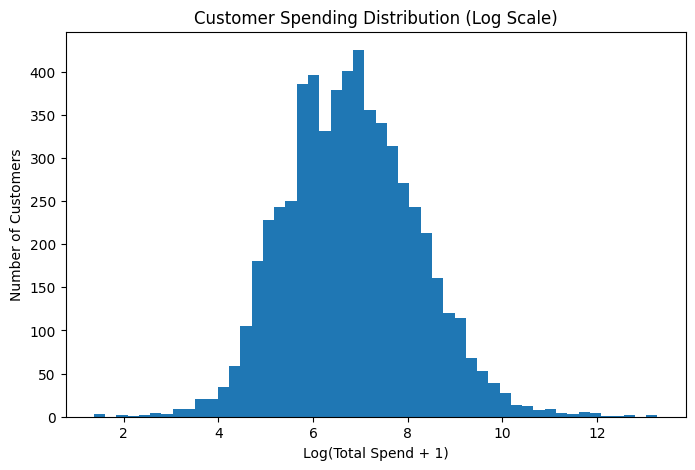

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(customer_spend), bins=50)
plt.title('Customer Spending Distribution (Log Scale)')
plt.xlabel('Log(Total Spend + 1)')
plt.ylabel('Number of Customers')
plt.show()

In [54]:
df.to_csv('cleaned_ecommerce_data.csv', index=False)